# Uzbekistan Power Sector — Exploratory Data Analysis
**Capstone Project | Notebook 02**  
**Author:** Farangiz Jurakhonova  
**Data:** `master_dataset_core.csv` (1990–2026, N=37)  

---
### Notebook Structure
1. Setup & Data Loading
2. Data Quality Assessment
3. Electricity Generation — Trends & Mix
4. Installed Capacity
5. Electricity Consumption
6. Renewable Energy Transition
7. CO₂ Emissions & Carbon Intensity
8. Gas Sector
9. Economic Context (GDP & Growth)
10. Correlation Analysis
11. Key Findings Summary

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.labelsize':   11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

# ── Colour palette ────────────────────────────────────────────────────
COLORS = {
    'gas':       '#E07B39',
    'hydro':     '#4A90D9',
    'coal':      '#7B6B63',
    'oil':       '#B5651D',
    'solar':     '#F5C518',
    'wind':      '#76C893',
    'fossil':    '#C0392B',
    'renewable': '#27AE60',
    'total':     '#2C3E50',
    'gdp':       '#8E44AD',
    'co2':       '#E74C3C',
    'accent':    '#2980B9',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# ── Load data ─────────────────────────────────────────────────────────
# Adjust path as needed
DATA_PATH = '../data/processed/master_dataset_core.csv'

df = pd.read_csv(DATA_PATH)
df = df.sort_values('year').reset_index(drop=True)

# Convenience subsets
df_confirmed = df[df['data_status'] == 'confirmed'].copy()  # 1990–2023
df_recent    = df[df['year'] >= 2010].copy()                # last 15 yrs

print(f'Full dataset:      {df.shape[0]} rows × {df.shape[1]} columns  |  {df["year"].min()}–{df["year"].max()}')
print(f'Confirmed only:    {df_confirmed.shape[0]} rows  |  {df_confirmed["year"].min()}–{df_confirmed["year"].max()}')
print(f'Recent (≥2010):    {df_recent.shape[0]} rows')

Full dataset:      37 rows × 33 columns  |  1990–2026
Confirmed only:    34 rows  |  1990–2023
Recent (≥2010):    17 rows


## 2. Data Quality Assessment

In [4]:
print('=== Basic Info ===')
print(df.dtypes.to_string())
print()
print('=== Summary Statistics ===')
df.describe().T.round(2)

=== Basic Info ===
year                               int64
elec_consumption_twh             float64
elec_consumption_twh_bridged     float64
gen_total_twh                    float64
gen_total_twh_bridged            float64
gen_gas_twh                      float64
gen_hydro_twh                    float64
gen_coal_twh                     float64
gen_solar_twh                    float64
gen_wind_twh                     float64
gen_fossil_twh                   float64
gen_renewable_twh                float64
re_penetration_pct               float64
fossil_share_pct                 float64
capacity_total_mw                float64
capacity_thermal_mw              float64
capacity_hydro_mw                float64
sc_solar_twh                     float64
sc_wind_twh                      float64
irena_re_share_generation_pct    float64
irena_re_share_capacity_pct      float64
sc_gas_prod_tj                   float64
sc_gas_cons_tj                   float64
gas_self_sufficiency_pct         float

,count,mean,std,min,25%,50%,75%,max
year,37.0,2008.00,10.82,1990.00,1999.00,2008.00,2017.00,2026.00
elec_consumption_twh,34.0,47.65,9.48,39.33,42.34,43.58,48.56,73.42
elec_consumption_twh_bridged,35.0,48.51,10.63,39.33,42.35,43.72,48.80,77.72
gen_total_twh,34.0,53.99,8.18,45.37,48.15,50.56,57.14,74.33
gen_total_twh_bridged,35.0,54.79,9.34,45.37,48.35,50.91,58.06,81.96
gen_gas_twh,34.0,42.53,8.40,31.61,36.71,40.42,47.96,61.03
gen_hydro_twh,34.0,6.23,1.17,3.53,5.72,6.23,6.85,8.93
gen_coal_twh,34.0,2.79,1.44,1.64,1.99,2.16,3.01,8.27
gen_solar_twh,7.0,0.16,0.26,0.00,0.00,0.00,0.24,0.62
gen_wind_twh,3.0,0.01,0.01,0.00,0.00,0.01,0.01,0.02


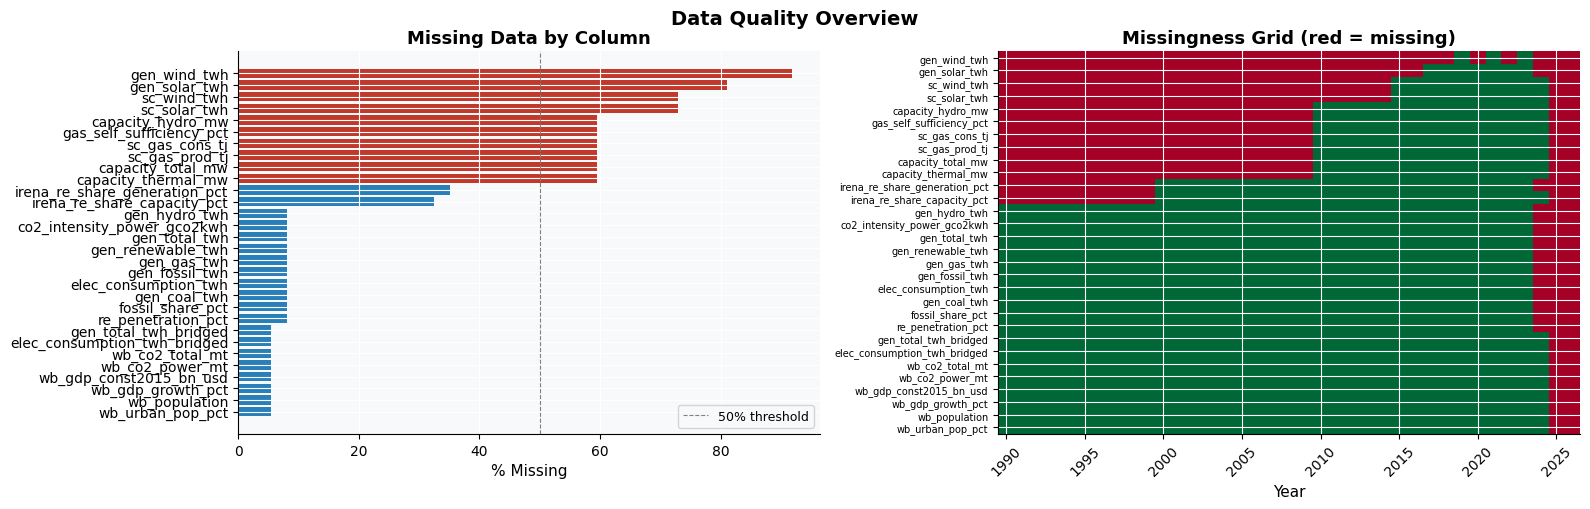


Columns with >80% missing (likely limited data availability):
gen_wind_twh     91.891892
gen_solar_twh    81.081081


In [5]:
# ── Missingness heatmap ───────────────────────────────────────────────
miss = df.isnull()
miss_pct = (miss.sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: bar chart of % missing per column
ax = axes[0]
bars = ax.barh(miss_pct.index[::-1], miss_pct.values[::-1],
               color=[COLORS['accent'] if v < 50 else COLORS['fossil'] for v in miss_pct.values[::-1]])
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, label='50% threshold')
ax.legend(fontsize=9)

# Right: binary missingness grid (years × columns)
ax2 = axes[1]
miss_cols = miss_pct.index.tolist()
im = ax2.imshow(miss[miss_cols].T.values.astype(int), aspect='auto',
                cmap='RdYlGn_r', vmin=0, vmax=1)
ax2.set_yticks(range(len(miss_cols)))
ax2.set_yticklabels(miss_cols, fontsize=7)
ax2.set_xticks(range(0, len(df), 5))
ax2.set_xticklabels(df['year'].iloc[::5].values, rotation=45)
ax2.set_title('Missingness Grid (red = missing)')
ax2.set_xlabel('Year')

plt.tight_layout()
plt.suptitle('Data Quality Overview', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print('\nColumns with >80% missing (likely limited data availability):')
print(miss_pct[miss_pct > 80].to_string())

In [6]:
# ── Data status breakdown ─────────────────────────────────────────────
status_counts = df['data_status'].value_counts()
prelim_years  = df[df['is_preliminary'] == 1]['year'].tolist()

print('Data status counts:')
print(status_counts.to_string())
print(f'\nPreliminary years: {prelim_years}')

Data status counts:
data_status
confirmed      34
preliminary     3

Preliminary years: [2024, 2025, 2026]


## 3. Electricity Generation — Trends & Mix

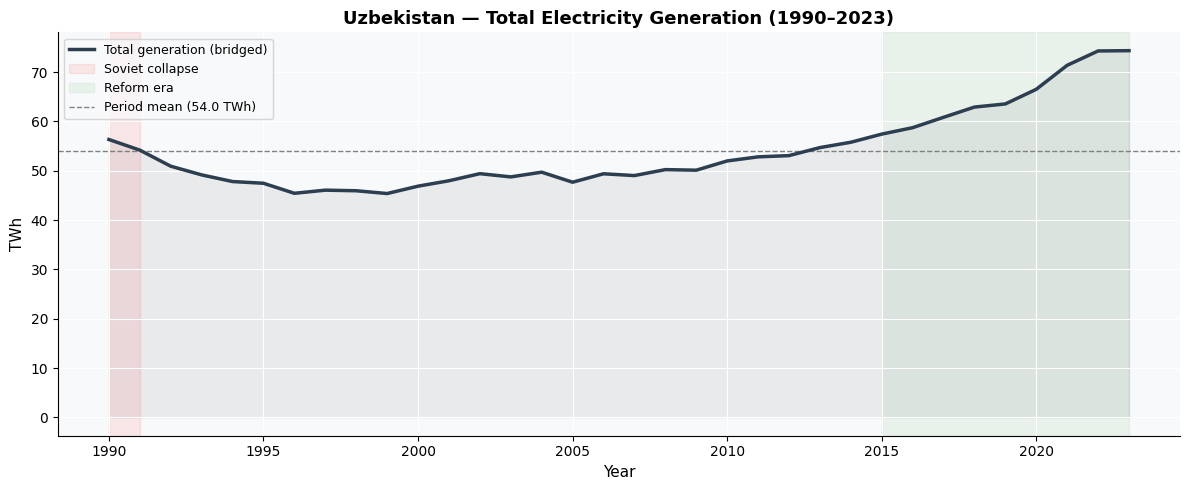

Min generation: 45.4 TWh (1999)
Max generation: 74.3 TWh (2023)


In [7]:
# ── 3.1 Total generation over time ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

dc = df_confirmed.copy()

ax.plot(dc['year'], dc['gen_total_twh_bridged'], color=COLORS['total'],
        linewidth=2.5, label='Total generation (bridged)', zorder=5)
ax.fill_between(dc['year'], dc['gen_total_twh_bridged'], alpha=0.08, color=COLORS['total'])

# Shade pre-/post-independence periods
ax.axvspan(1990, 1991, alpha=0.08, color='red', label='Soviet collapse')
ax.axvspan(2015, 2023, alpha=0.06, color='green', label='Reform era')

ax.axhline(dc['gen_total_twh_bridged'].mean(), color='grey', linestyle='--',
           linewidth=1, label=f'Period mean ({dc["gen_total_twh_bridged"].mean():.1f} TWh)')

ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.set_title('Uzbekistan — Total Electricity Generation (1990–2023)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Min generation: {dc["gen_total_twh_bridged"].min():.1f} TWh ({dc.loc[dc["gen_total_twh_bridged"].idxmin(),"year"]})')
print(f'Max generation: {dc["gen_total_twh_bridged"].max():.1f} TWh ({dc.loc[dc["gen_total_twh_bridged"].idxmax(),"year"]})')

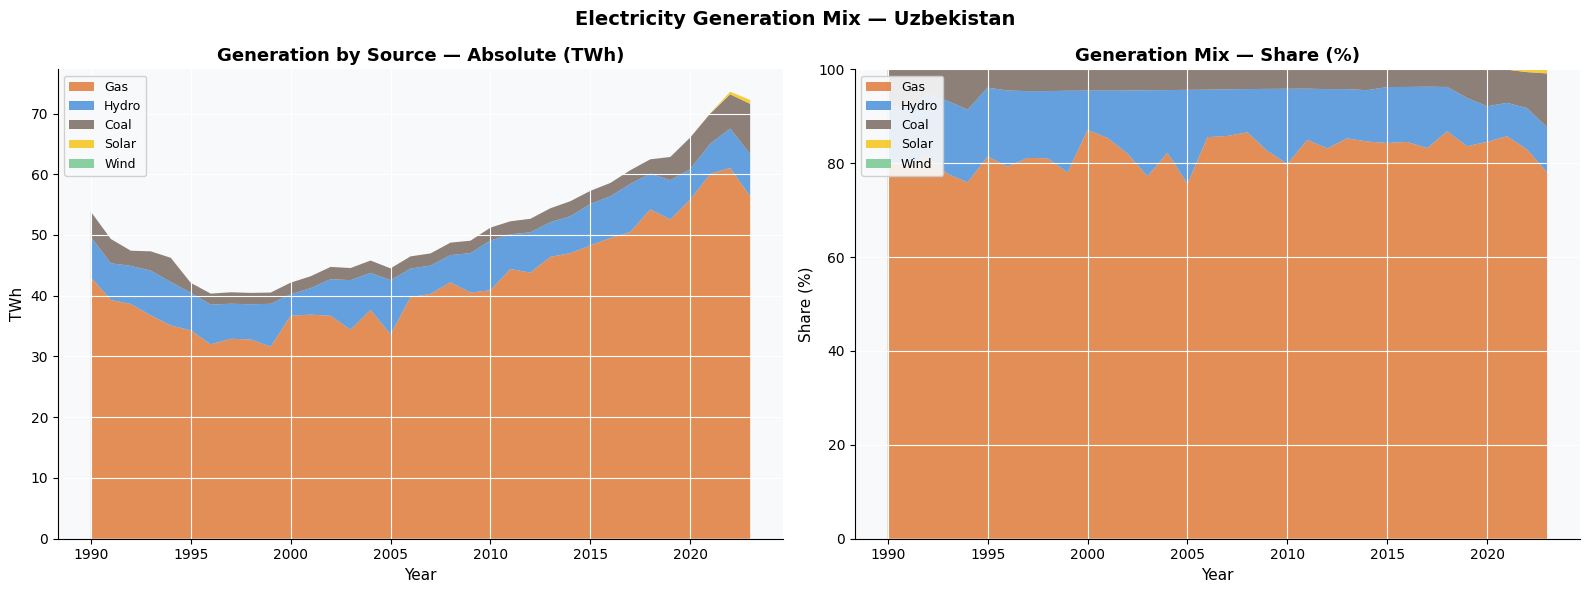

In [8]:
# ── 3.2 Stacked area: generation by source ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

src_cols   = ['gen_gas_twh', 'gen_hydro_twh', 'gen_coal_twh', 'gen_solar_twh', 'gen_wind_twh']
src_labels = ['Gas', 'Hydro', 'Coal', 'Solar', 'Wind']
src_colors = [COLORS['gas'], COLORS['hydro'], COLORS['coal'], COLORS['solar'], COLORS['wind']]

dc_fill = dc[['year'] + src_cols].fillna(0)

# -- Stacked area
ax = axes[0]
ax.stackplot(dc_fill['year'],
             [dc_fill[c] for c in src_cols],
             labels=src_labels,
             colors=src_colors, alpha=0.85)
ax.set_xlabel('Year')
ax.set_ylabel('TWh')
ax.set_title('Generation by Source — Absolute (TWh)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

# -- 100% stacked (share)
ax2 = axes[1]
totals = dc_fill[src_cols].sum(axis=1)
pcts   = dc_fill[src_cols].div(totals, axis=0) * 100

ax2.stackplot(dc_fill['year'],
              [pcts[c] for c in src_cols],
              labels=src_labels,
              colors=src_colors, alpha=0.85)
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.set_title('Generation Mix — Share (%)')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.suptitle('Electricity Generation Mix — Uzbekistan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

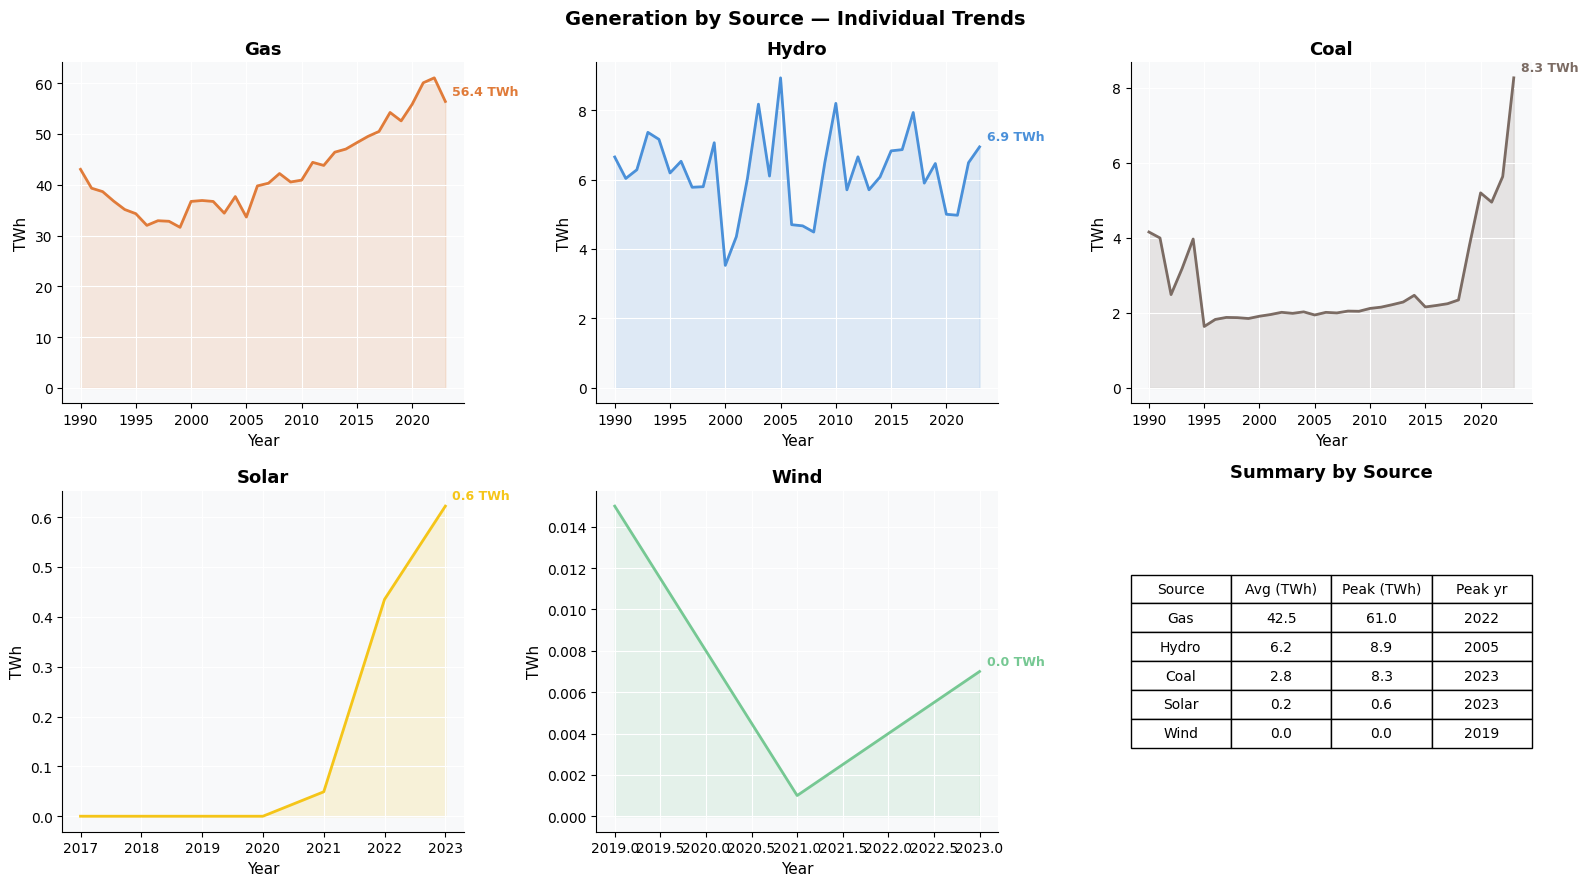

In [9]:
# ── 3.3 Source-by-source line plots ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(src_cols, src_labels, src_colors)):
    ax = axes[i]
    sub = dc[['year', col]].dropna()
    ax.plot(sub['year'], sub[col], color=color, linewidth=2)
    ax.fill_between(sub['year'], sub[col], alpha=0.15, color=color)
    ax.set_title(f'{label}')
    ax.set_ylabel('TWh')
    ax.set_xlabel('Year')
    # Annotate latest value
    if not sub.empty:
        last = sub.iloc[-1]
        ax.annotate(f"{last[col]:.1f} TWh",
                    xy=(last['year'], last[col]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold')

# Hide unused subplot
axes[-1].axis('off')

# Summary stats table in last panel
ax_t = axes[-1]
ax_t.axis('off')
stats = []
for col, label in zip(src_cols, src_labels):
    s = dc[col].dropna()
    stats.append([label, f'{s.mean():.1f}', f'{s.max():.1f}',
                  f'{dc.loc[s.idxmax(), "year"]}' if not s.empty else 'N/A'])

tbl = ax_t.table(cellText=stats,
                 colLabels=['Source', 'Avg (TWh)', 'Peak (TWh)', 'Peak yr'],
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
ax_t.set_title('Summary by Source', fontweight='bold', pad=10)

plt.suptitle('Generation by Source — Individual Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Installed Capacity

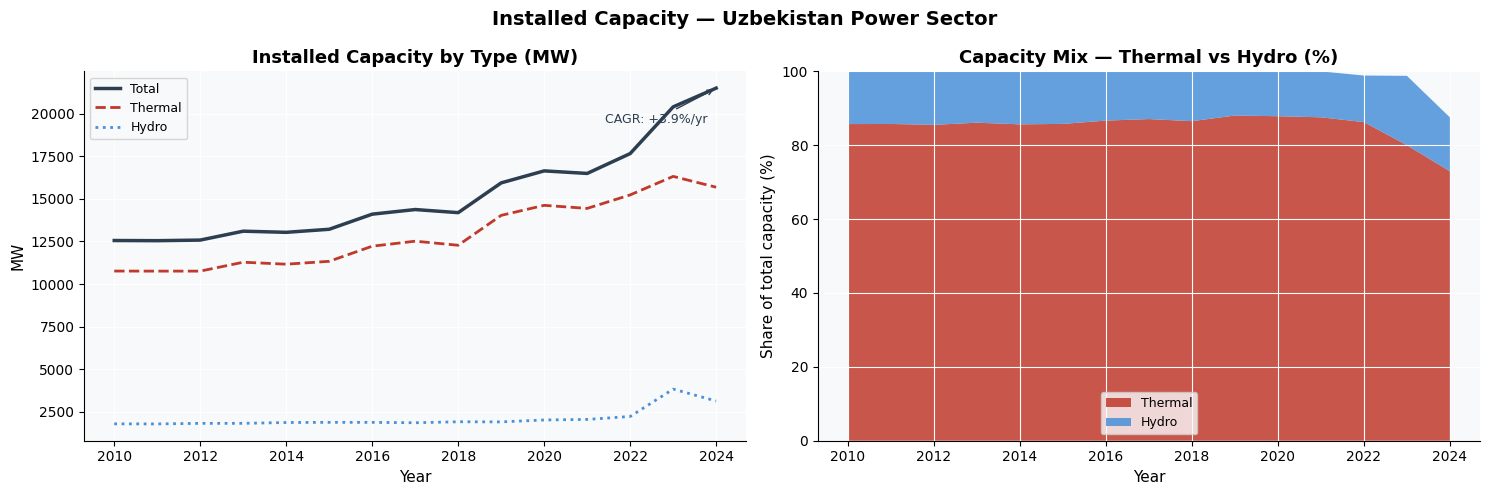

Latest total capacity (2024): 21,501 MW
  of which Thermal: 15,684 MW (72.9%)
  of which Hydro:   3,134 MW (14.6%)


In [10]:
cap_df = df[['year', 'capacity_total_mw', 'capacity_thermal_mw', 'capacity_hydro_mw']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- Absolute capacity
ax = axes[0]
ax.plot(cap_df['year'], cap_df['capacity_total_mw'],   color=COLORS['total'],   lw=2.5, label='Total')
ax.plot(cap_df['year'], cap_df['capacity_thermal_mw'], color=COLORS['fossil'],  lw=2,   label='Thermal', linestyle='--')
ax.plot(cap_df['year'], cap_df['capacity_hydro_mw'],   color=COLORS['hydro'],   lw=2,   label='Hydro',   linestyle=':')
ax.set_ylabel('MW')
ax.set_xlabel('Year')
ax.set_title('Installed Capacity by Type (MW)')
ax.legend(fontsize=9)

# Annotate CAGR
cap_total = cap_df['capacity_total_mw']
n_yrs = cap_df['year'].iloc[-1] - cap_df['year'].iloc[0]
cagr  = ((cap_total.iloc[-1] / cap_total.iloc[0]) ** (1 / n_yrs) - 1) * 100
ax.annotate(f'CAGR: +{cagr:.1f}%/yr',
            xy=(cap_df['year'].iloc[-1], cap_total.iloc[-1]),
            xytext=(-80, -25), textcoords='offset points',
            fontsize=9, color=COLORS['total'],
            arrowprops=dict(arrowstyle='->', color=COLORS['total']))

# -- Thermal vs Hydro share
ax2 = axes[1]
hydro_share   = cap_df['capacity_hydro_mw']   / cap_df['capacity_total_mw'] * 100
thermal_share = cap_df['capacity_thermal_mw'] / cap_df['capacity_total_mw'] * 100

ax2.stackplot(cap_df['year'],
              [thermal_share, hydro_share],
              labels=['Thermal', 'Hydro'],
              colors=[COLORS['fossil'], COLORS['hydro']], alpha=0.85)
ax2.set_ylim(0, 100)
ax2.set_ylabel('Share of total capacity (%)')
ax2.set_xlabel('Year')
ax2.set_title('Capacity Mix — Thermal vs Hydro (%)')
ax2.legend(fontsize=9)

plt.suptitle('Installed Capacity — Uzbekistan Power Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Latest total capacity ({cap_df['year'].iloc[-1]}): {cap_df['capacity_total_mw'].iloc[-1]:,.0f} MW")
print(f"  of which Thermal: {cap_df['capacity_thermal_mw'].iloc[-1]:,.0f} MW ({thermal_share.iloc[-1]:.1f}%)")
print(f"  of which Hydro:   {cap_df['capacity_hydro_mw'].iloc[-1]:,.0f} MW ({hydro_share.iloc[-1]:.1f}%)")

## 5. Electricity Consumption

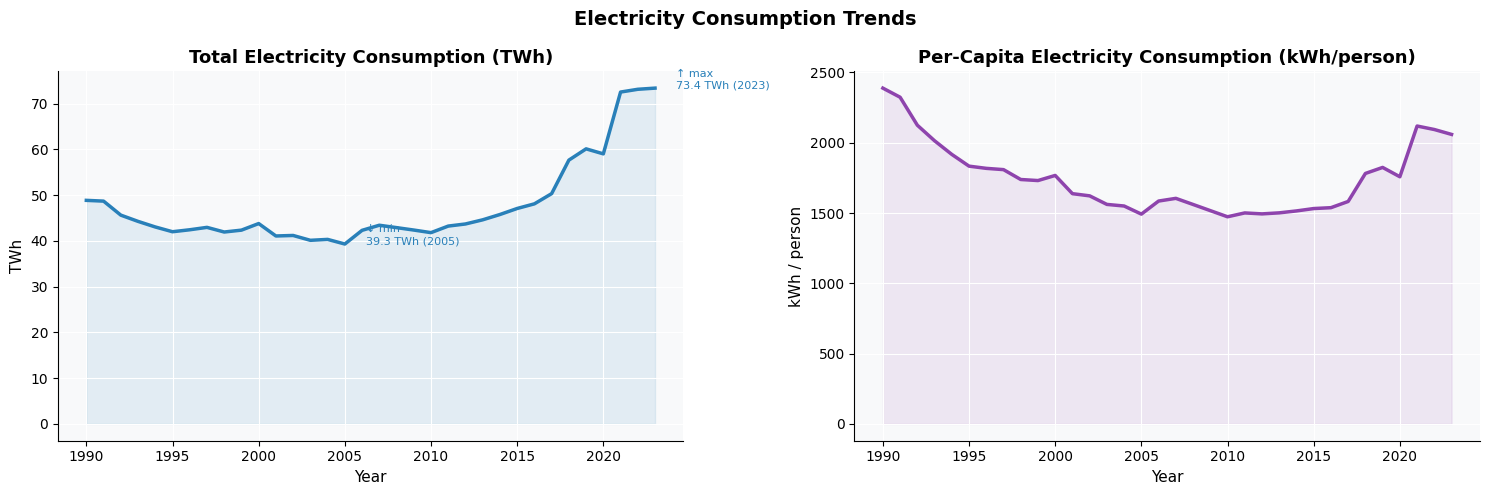

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cons = df_confirmed[['year', 'elec_consumption_twh_bridged', 'wb_population']].dropna()

# -- Total consumption
ax = axes[0]
ax.plot(cons['year'], cons['elec_consumption_twh_bridged'],
        color=COLORS['accent'], lw=2.5)
ax.fill_between(cons['year'], cons['elec_consumption_twh_bridged'],
                alpha=0.1, color=COLORS['accent'])
ax.set_ylabel('TWh')
ax.set_xlabel('Year')
ax.set_title('Total Electricity Consumption (TWh)')

# Annotate min/max
idx_min = cons['elec_consumption_twh_bridged'].idxmin()
idx_max = cons['elec_consumption_twh_bridged'].idxmax()
for idx, prefix in [(idx_min, '↓ min'), (idx_max, '↑ max')]:
    r = cons.loc[idx]
    ax.annotate(f"{prefix}\n{r['elec_consumption_twh_bridged']:.1f} TWh ({int(r['year'])})",
                xy=(r['year'], r['elec_consumption_twh_bridged']),
                xytext=(15, 0), textcoords='offset points',
                fontsize=8, color=COLORS['accent'])

# -- Per-capita consumption (derived)
ax2 = axes[1]
per_cap = cons['elec_consumption_twh_bridged'] * 1e9 / cons['wb_population']  # kWh/person
ax2.plot(cons['year'], per_cap, color=COLORS['gdp'], lw=2.5)
ax2.fill_between(cons['year'], per_cap, alpha=0.1, color=COLORS['gdp'])
ax2.set_ylabel('kWh / person')
ax2.set_xlabel('Year')
ax2.set_title('Per-Capita Electricity Consumption (kWh/person)')

plt.suptitle('Electricity Consumption Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

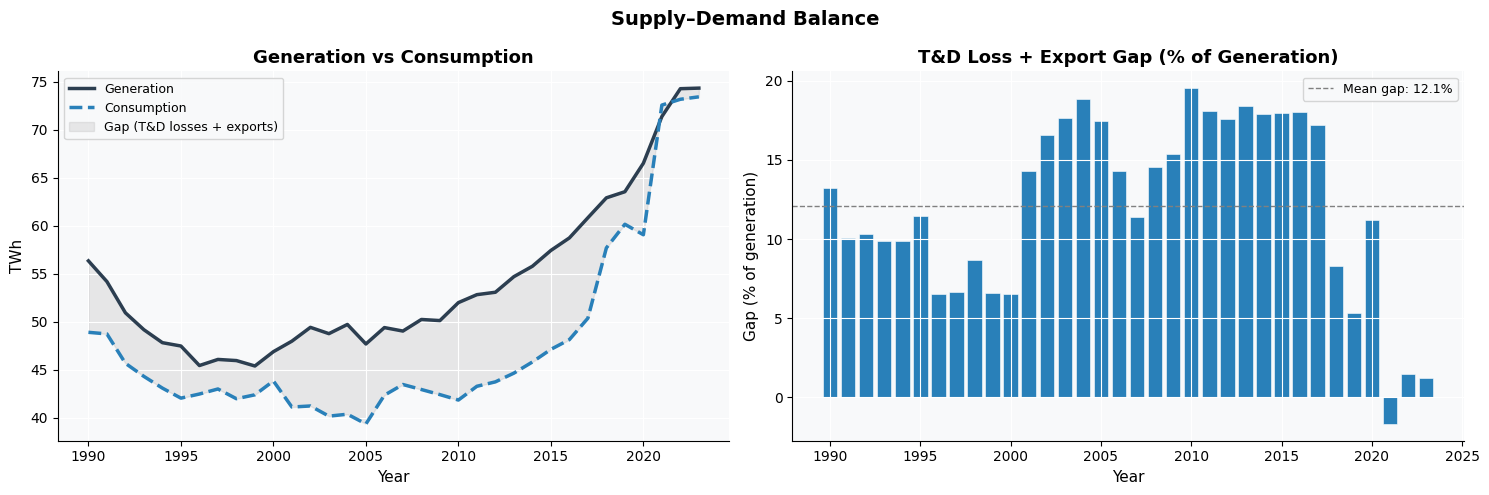

Average gap: 12.1%
Latest gap (2023): 1.2%


In [12]:
# ── Generation–Consumption gap (losses / exports) ─────────────────────
gap_df = df_confirmed[['year', 'gen_total_twh_bridged', 'elec_consumption_twh_bridged']].dropna()
gap_df['gap_twh'] = gap_df['gen_total_twh_bridged'] - gap_df['elec_consumption_twh_bridged']
gap_df['gap_pct'] = gap_df['gap_twh'] / gap_df['gen_total_twh_bridged'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(gap_df['year'], gap_df['gen_total_twh_bridged'],   color=COLORS['total'],  lw=2.5, label='Generation')
ax.plot(gap_df['year'], gap_df['elec_consumption_twh_bridged'], color=COLORS['accent'], lw=2.5, label='Consumption', linestyle='--')
ax.fill_between(gap_df['year'],
                gap_df['elec_consumption_twh_bridged'],
                gap_df['gen_total_twh_bridged'],
                alpha=0.15, color='grey', label='Gap (T&D losses + exports)')
ax.set_ylabel('TWh')
ax.set_xlabel('Year')
ax.set_title('Generation vs Consumption')
ax.legend(fontsize=9)

ax2 = axes[1]
colors_gap = [COLORS['fossil'] if v > 20 else COLORS['accent'] for v in gap_df['gap_pct']]
ax2.bar(gap_df['year'], gap_df['gap_pct'], color=colors_gap, edgecolor='white', linewidth=0.4)
ax2.axhline(gap_df['gap_pct'].mean(), color='grey', linestyle='--', linewidth=1,
            label=f'Mean gap: {gap_df["gap_pct"].mean():.1f}%')
ax2.set_ylabel('Gap (% of generation)')
ax2.set_xlabel('Year')
ax2.set_title('T&D Loss + Export Gap (% of Generation)')
ax2.legend(fontsize=9)

plt.suptitle('Supply–Demand Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average gap: {gap_df['gap_pct'].mean():.1f}%")
print(f"Latest gap ({gap_df['year'].iloc[-1]}): {gap_df['gap_pct'].iloc[-1]:.1f}%")

## 6. Renewable Energy Transition

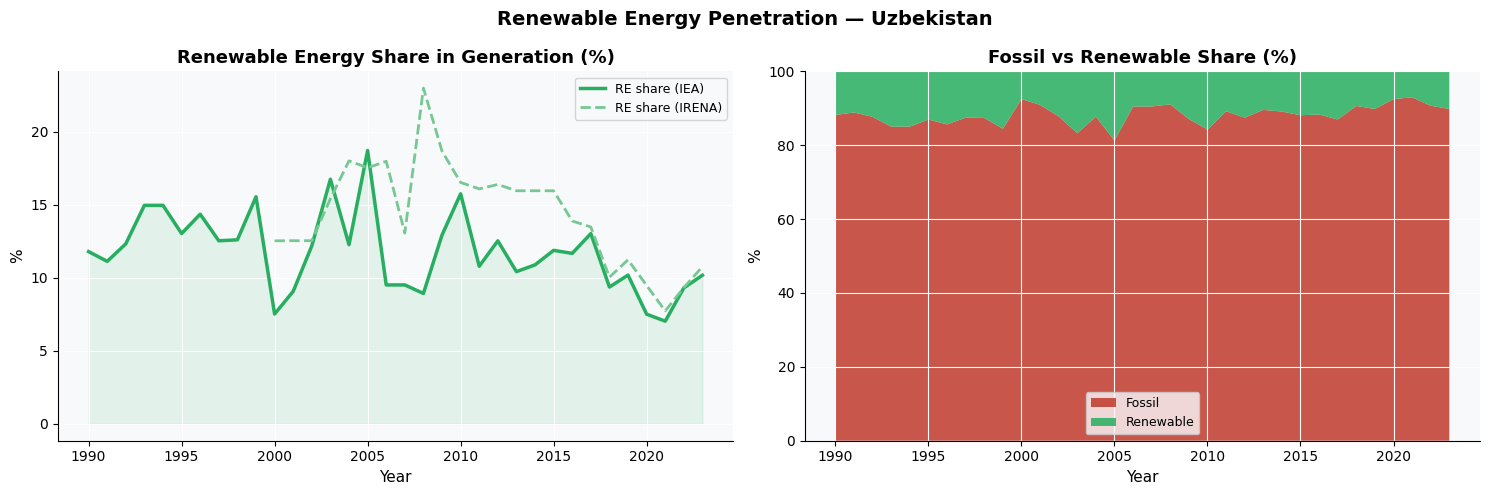

In [13]:
re_df = df_confirmed[['year', 're_penetration_pct', 'fossil_share_pct',
                       'irena_re_share_generation_pct', 'irena_re_share_capacity_pct']].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- RE penetration over time
ax = axes[0]
ax.plot(re_df['year'], re_df['re_penetration_pct'],
        color=COLORS['renewable'], lw=2.5, label='RE share (IEA)')
ax.plot(re_df['year'], re_df['irena_re_share_generation_pct'],
        color=COLORS['wind'], lw=2, linestyle='--', label='RE share (IRENA)')
ax.fill_between(re_df['year'], re_df['re_penetration_pct'],
                alpha=0.1, color=COLORS['renewable'])
ax.set_ylabel('%')
ax.set_xlabel('Year')
ax.set_title('Renewable Energy Share in Generation (%)')
ax.legend(fontsize=9)

# -- Fossil vs RE share
ax2 = axes[1]
re_plot = re_df.dropna(subset=['re_penetration_pct'])
ax2.stackplot(re_plot['year'],
              [re_plot['fossil_share_pct'], re_plot['re_penetration_pct']],
              labels=['Fossil', 'Renewable'],
              colors=[COLORS['fossil'], COLORS['renewable']], alpha=0.85)
ax2.set_ylim(0, 100)
ax2.set_ylabel('%')
ax2.set_xlabel('Year')
ax2.set_title('Fossil vs Renewable Share (%)')
ax2.legend(fontsize=9)

plt.suptitle('Renewable Energy Penetration — Uzbekistan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

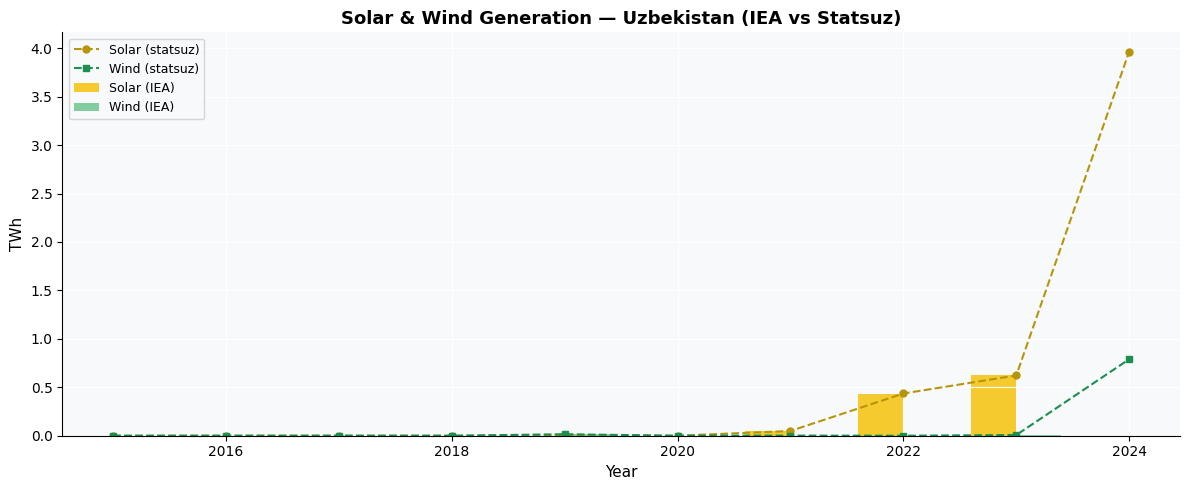

Solar generation non-zero years:
 year  gen_solar_twh
 2021          0.049
 2022          0.435
 2023          0.622


In [14]:
# ── Solar & Wind absolute generation ─────────────────────────────────
sol_wind = df[['year', 'gen_solar_twh', 'gen_wind_twh', 'sc_solar_twh', 'sc_wind_twh']].dropna(subset=['gen_solar_twh'])

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(sol_wind['year'] - 0.2, sol_wind['gen_solar_twh'].fillna(0),
       width=0.4, color=COLORS['solar'], label='Solar (IEA)', alpha=0.9)
ax.bar(sol_wind['year'] + 0.2, sol_wind['gen_wind_twh'].fillna(0),
       width=0.4, color=COLORS['wind'], label='Wind (IEA)', alpha=0.9)

# Overlay statsuz if available
sc_s = df[['year', 'sc_solar_twh']].dropna()
sc_w = df[['year', 'sc_wind_twh']].dropna()
if not sc_s.empty:
    ax.plot(sc_s['year'], sc_s['sc_solar_twh'], 'o--', color='#B7950B', label='Solar (statsuz)', markersize=5)
if not sc_w.empty:
    ax.plot(sc_w['year'], sc_w['sc_wind_twh'], 's--', color='#1A8F50', label='Wind (statsuz)', markersize=5)

ax.set_ylabel('TWh')
ax.set_xlabel('Year')
ax.set_title('Solar & Wind Generation — Uzbekistan (IEA vs Statsuz)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Solar generation non-zero years:')
print(df[df['gen_solar_twh'] > 0][['year', 'gen_solar_twh']].to_string(index=False))

## 7. CO₂ Emissions & Carbon Intensity

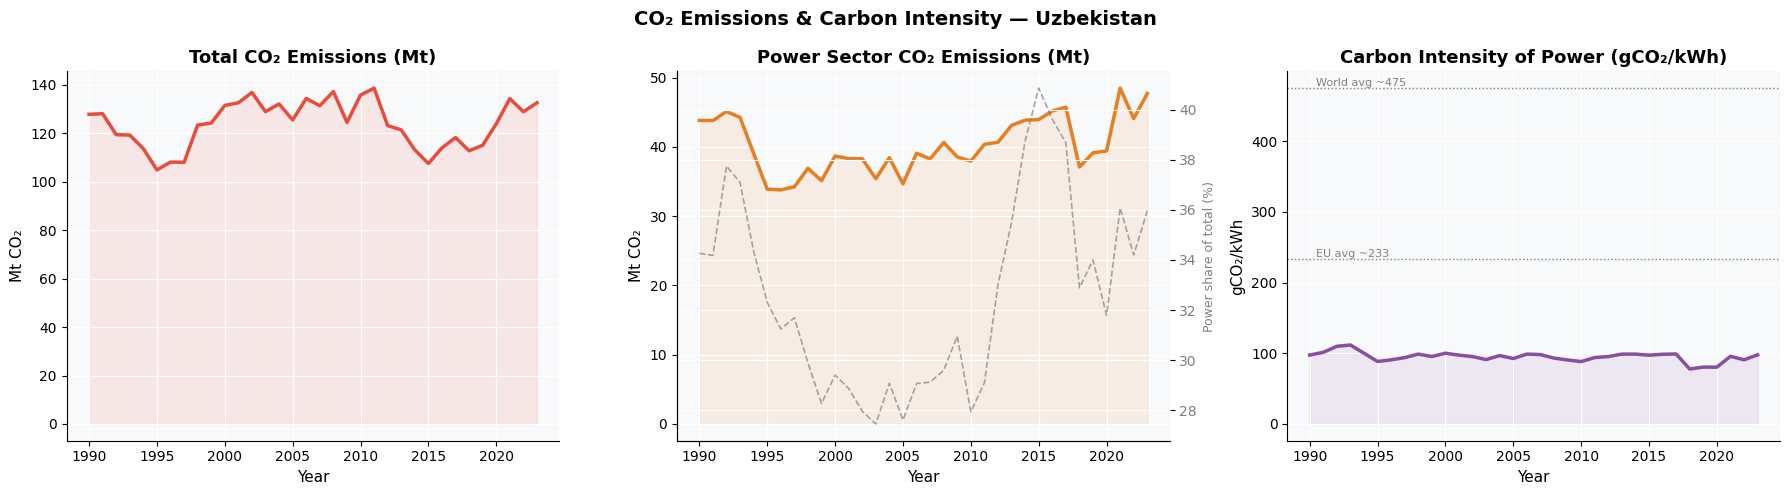

Peak intensity: 112 gCO2/kWh (1993)
Latest intensity: 98 gCO2/kWh (2023)


In [15]:
co2_df = df_confirmed[['year', 'wb_co2_total_mt', 'wb_co2_power_mt', 'co2_intensity_power_gco2kwh']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Total CO2
ax = axes[0]
ax.plot(co2_df['year'], co2_df['wb_co2_total_mt'], color=COLORS['co2'], lw=2.5)
ax.fill_between(co2_df['year'], co2_df['wb_co2_total_mt'], alpha=0.1, color=COLORS['co2'])
ax.set_ylabel('Mt CO₂')
ax.set_xlabel('Year')
ax.set_title('Total CO₂ Emissions (Mt)')

# -- Power sector CO2
ax2 = axes[1]
ax2.plot(co2_df['year'], co2_df['wb_co2_power_mt'], color='#E67E22', lw=2.5)
ax2.fill_between(co2_df['year'], co2_df['wb_co2_power_mt'], alpha=0.1, color='#E67E22')
power_share = co2_df['wb_co2_power_mt'] / co2_df['wb_co2_total_mt'] * 100
ax2.set_ylabel('Mt CO₂')
ax2.set_xlabel('Year')
ax2.set_title('Power Sector CO₂ Emissions (Mt)')
ax2_r = ax2.twinx()
ax2_r.plot(co2_df['year'], power_share, color='grey', lw=1.2, linestyle='--', alpha=0.7)
ax2_r.set_ylabel('Power share of total (%)', color='grey', fontsize=9)
ax2_r.tick_params(axis='y', labelcolor='grey')

# -- Carbon intensity
ax3 = axes[2]
ci = co2_df.dropna(subset=['co2_intensity_power_gco2kwh'])
ax3.plot(ci['year'], ci['co2_intensity_power_gco2kwh'], color='#884EA0', lw=2.5)
ax3.fill_between(ci['year'], ci['co2_intensity_power_gco2kwh'], alpha=0.1, color='#884EA0')
ax3.set_ylabel('gCO₂/kWh')
ax3.set_xlabel('Year')
ax3.set_title('Carbon Intensity of Power (gCO₂/kWh)')

# Reference lines for comparison
for line, label in [(475, 'World avg ~475'), (233, 'EU avg ~233')]:
    ax3.axhline(line, linestyle=':', color='grey', linewidth=1)
    ax3.text(ci['year'].min() + 0.5, line + 3, label, fontsize=8, color='grey')

plt.suptitle('CO₂ Emissions & Carbon Intensity — Uzbekistan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Peak intensity: {ci['co2_intensity_power_gco2kwh'].max():.0f} gCO2/kWh ({ci.loc[ci['co2_intensity_power_gco2kwh'].idxmax(),'year']})")
print(f"Latest intensity: {ci['co2_intensity_power_gco2kwh'].iloc[-1]:.0f} gCO2/kWh ({ci['year'].iloc[-1]})")

## 8. Gas Sector

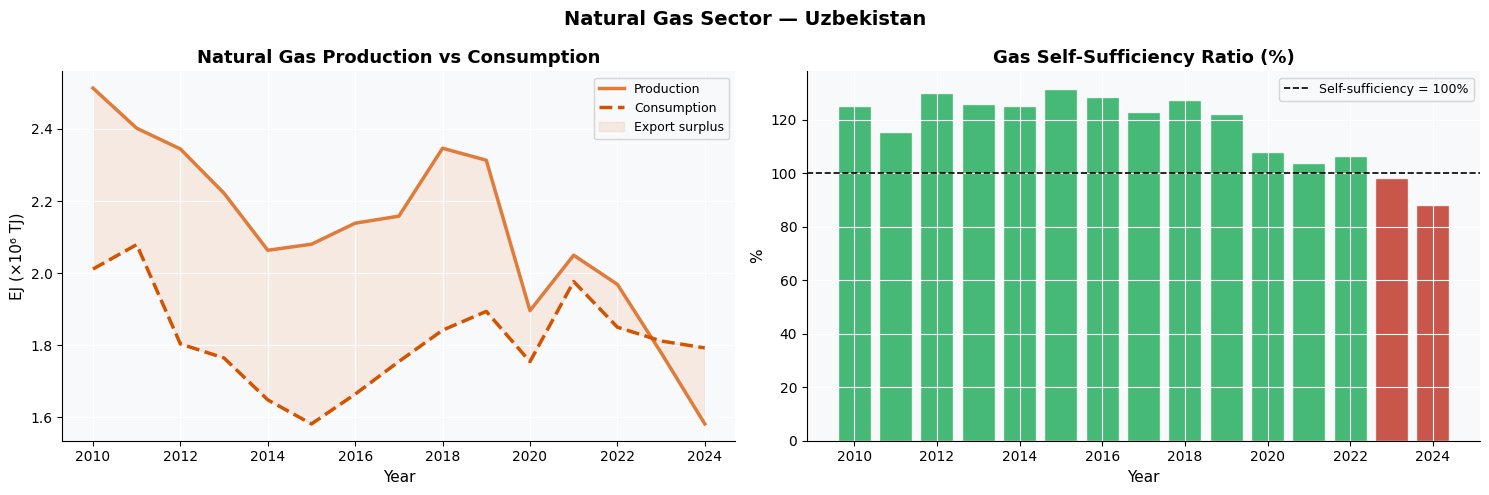

Average self-sufficiency: 117.2%
Latest self-sufficiency (2024): 88.2%


In [16]:
gas_df = df[['year', 'sc_gas_prod_tj', 'sc_gas_cons_tj', 'gas_self_sufficiency_pct']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- Production vs consumption
ax = axes[0]
ax.plot(gas_df['year'], gas_df['sc_gas_prod_tj'] / 1e6,
        color=COLORS['gas'], lw=2.5, label='Production')
ax.plot(gas_df['year'], gas_df['sc_gas_cons_tj'] / 1e6,
        color='#D35400', lw=2.5, linestyle='--', label='Consumption')
ax.fill_between(gas_df['year'],
                gas_df['sc_gas_cons_tj'] / 1e6,
                gas_df['sc_gas_prod_tj']  / 1e6,
                alpha=0.12, color=COLORS['gas'], label='Export surplus')
ax.set_ylabel('EJ (×10⁶ TJ)')
ax.set_xlabel('Year')
ax.set_title('Natural Gas Production vs Consumption')
ax.legend(fontsize=9)

# -- Self-sufficiency ratio
ax2 = axes[1]
colors_ss = [COLORS['renewable'] if v >= 100 else COLORS['fossil'] for v in gas_df['gas_self_sufficiency_pct']]
ax2.bar(gas_df['year'], gas_df['gas_self_sufficiency_pct'], color=colors_ss, alpha=0.85, edgecolor='white')
ax2.axhline(100, color='black', linewidth=1.2, linestyle='--', label='Self-sufficiency = 100%')
ax2.set_ylabel('%')
ax2.set_xlabel('Year')
ax2.set_title('Gas Self-Sufficiency Ratio (%)')
ax2.legend(fontsize=9)

plt.suptitle('Natural Gas Sector — Uzbekistan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average self-sufficiency: {gas_df['gas_self_sufficiency_pct'].mean():.1f}%")
print(f"Latest self-sufficiency ({gas_df['year'].iloc[-1]}): {gas_df['gas_self_sufficiency_pct'].iloc[-1]:.1f}%")

## 9. Economic Context

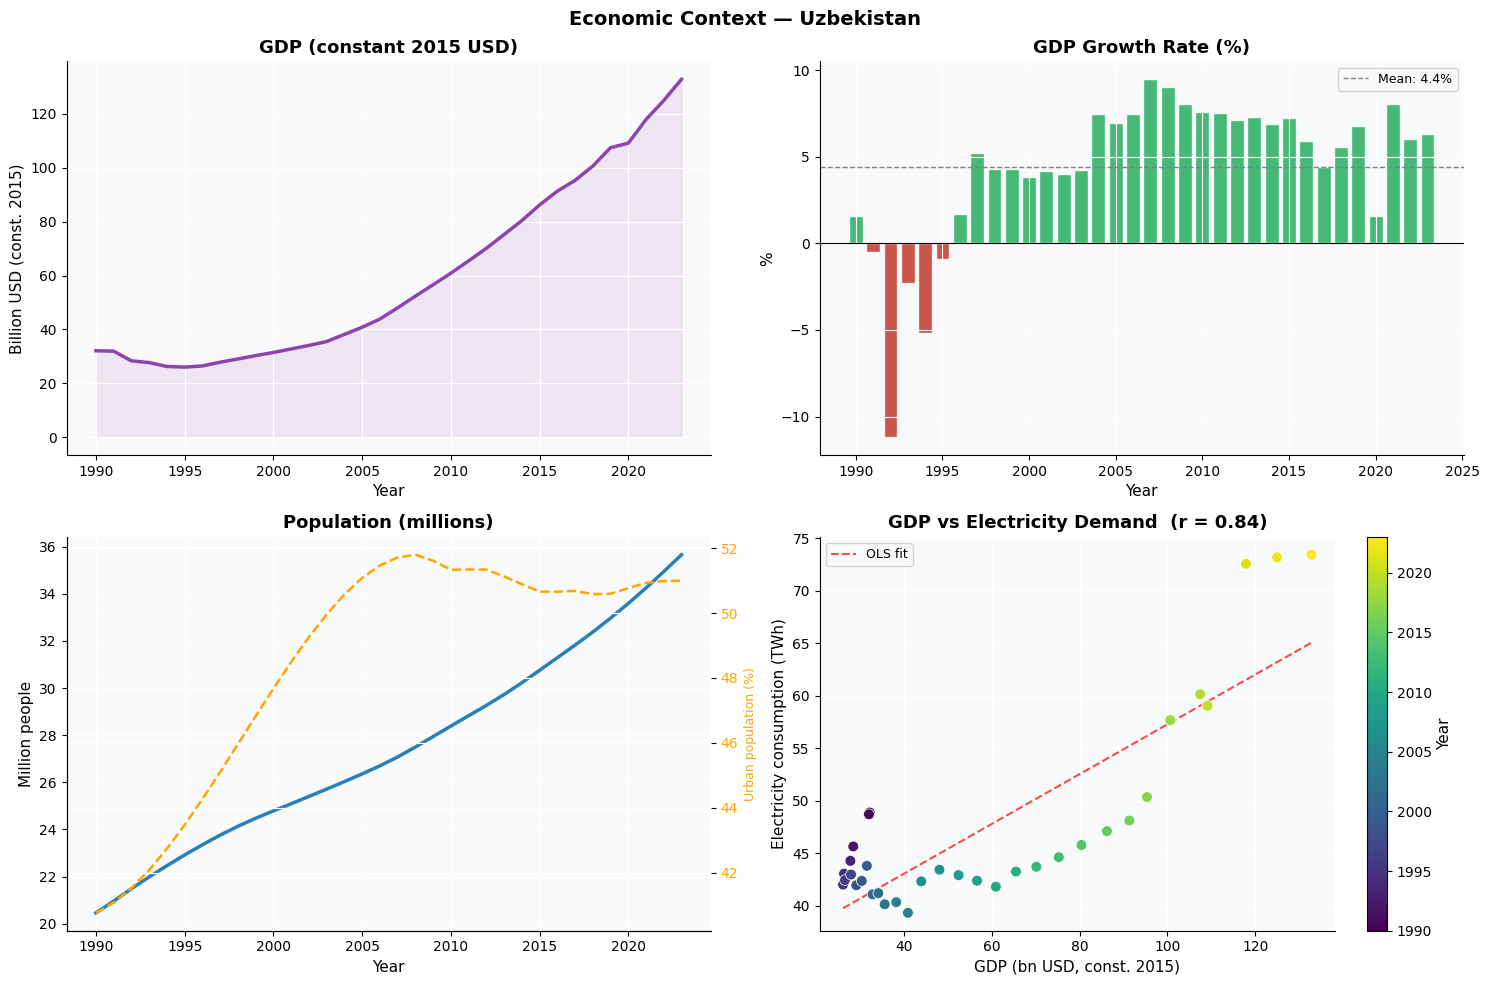

In [17]:
econ_df = df_confirmed[['year', 'wb_gdp_const2015_bn_usd', 'wb_gdp_growth_pct',
                         'wb_population', 'wb_urban_pop_pct',
                         'elec_consumption_twh_bridged']].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -- GDP trajectory
ax = axes[0, 0]
ax.plot(econ_df['year'], econ_df['wb_gdp_const2015_bn_usd'],
        color=COLORS['gdp'], lw=2.5)
ax.fill_between(econ_df['year'], econ_df['wb_gdp_const2015_bn_usd'], alpha=0.1, color=COLORS['gdp'])
ax.set_ylabel('Billion USD (const. 2015)')
ax.set_xlabel('Year')
ax.set_title('GDP (constant 2015 USD)')

# -- GDP growth rate
ax2 = axes[0, 1]
colors_g = [COLORS['renewable'] if g > 0 else COLORS['fossil'] for g in econ_df['wb_gdp_growth_pct']]
ax2.bar(econ_df['year'], econ_df['wb_gdp_growth_pct'], color=colors_g, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(econ_df['wb_gdp_growth_pct'].mean(), color='grey', linestyle='--', linewidth=1,
            label=f'Mean: {econ_df["wb_gdp_growth_pct"].mean():.1f}%')
ax2.set_ylabel('%')
ax2.set_xlabel('Year')
ax2.set_title('GDP Growth Rate (%)')
ax2.legend(fontsize=9)

# -- Population & urbanisation
ax3 = axes[1, 0]
ax3.plot(econ_df['year'], econ_df['wb_population'] / 1e6, color=COLORS['accent'], lw=2.5)
ax3.set_ylabel('Million people')
ax3.set_xlabel('Year')
ax3.set_title('Population (millions)')
ax3_r = ax3.twinx()
ax3_r.plot(econ_df['year'], econ_df['wb_urban_pop_pct'], color='orange', lw=1.8, linestyle='--')
ax3_r.set_ylabel('Urban population (%)', color='orange', fontsize=9)
ax3_r.tick_params(axis='y', labelcolor='orange')

# -- GDP vs electricity demand scatter
ax4 = axes[1, 1]
sc = ax4.scatter(econ_df['wb_gdp_const2015_bn_usd'], econ_df['elec_consumption_twh_bridged'],
                 c=econ_df['year'], cmap='viridis', s=60, zorder=5, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax4, label='Year')

# Trend line
m, b = np.polyfit(econ_df['wb_gdp_const2015_bn_usd'], econ_df['elec_consumption_twh_bridged'], 1)
x_line = np.linspace(econ_df['wb_gdp_const2015_bn_usd'].min(), econ_df['wb_gdp_const2015_bn_usd'].max(), 100)
ax4.plot(x_line, m * x_line + b, color='red', lw=1.5, linestyle='--', alpha=0.7, label=f'OLS fit')

r = econ_df['wb_gdp_const2015_bn_usd'].corr(econ_df['elec_consumption_twh_bridged'])
ax4.set_xlabel('GDP (bn USD, const. 2015)')
ax4.set_ylabel('Electricity consumption (TWh)')
ax4.set_title(f'GDP vs Electricity Demand  (r = {r:.2f})')
ax4.legend(fontsize=9)

plt.suptitle('Economic Context — Uzbekistan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

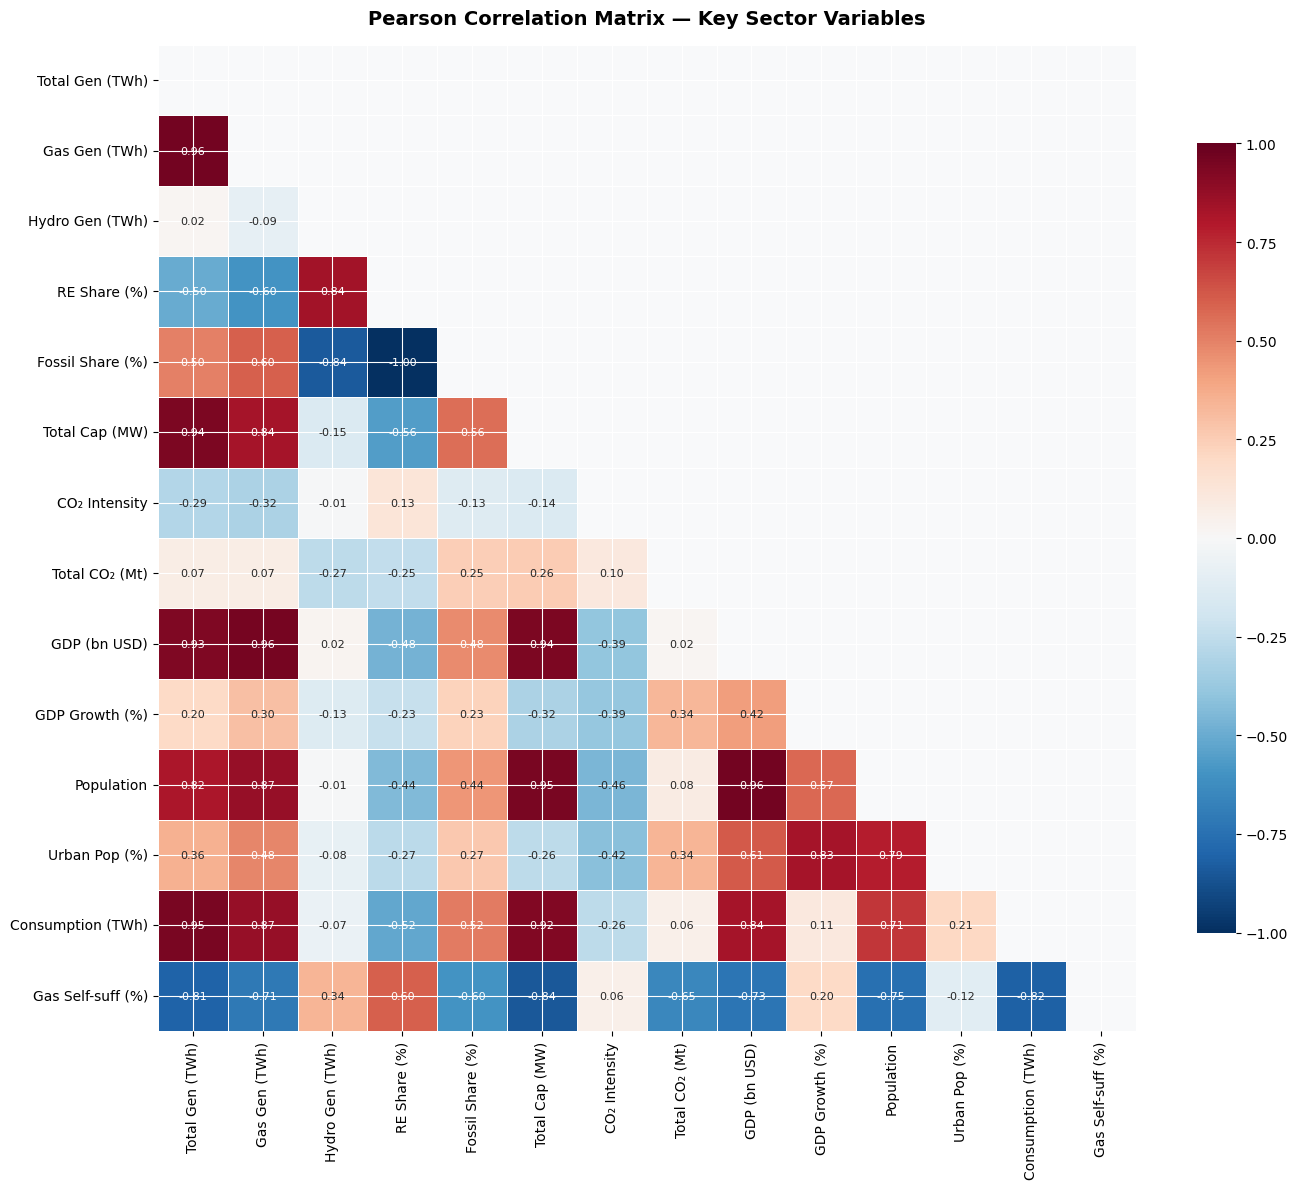


Top correlations with GDP:
Population           0.961883
Gas Gen (TWh)        0.958193
Total Cap (MW)       0.941918
Total Gen (TWh)      0.931354
Consumption (TWh)    0.835309
Gas Self-suff (%)    0.729574
Urban Pop (%)        0.612413
RE Share (%)         0.476105


In [18]:
# ── Select key variables for correlation matrix ───────────────────────
corr_cols = {
    'gen_total_twh_bridged':       'Total Gen (TWh)',
    'gen_gas_twh':                 'Gas Gen (TWh)',
    'gen_hydro_twh':               'Hydro Gen (TWh)',
    're_penetration_pct':          'RE Share (%)',
    'fossil_share_pct':            'Fossil Share (%)',
    'capacity_total_mw':           'Total Cap (MW)',
    'co2_intensity_power_gco2kwh': 'CO₂ Intensity',
    'wb_co2_total_mt':             'Total CO₂ (Mt)',
    'wb_gdp_const2015_bn_usd':     'GDP (bn USD)',
    'wb_gdp_growth_pct':           'GDP Growth (%)',
    'wb_population':               'Population',
    'wb_urban_pop_pct':            'Urban Pop (%)',
    'elec_consumption_twh_bridged':'Consumption (TWh)',
    'gas_self_sufficiency_pct':    'Gas Self-suff (%)',
}

corr_df = df_confirmed[list(corr_cols.keys())].copy()
corr_df.columns = list(corr_cols.values())
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix — Key Sector Variables',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with GDP
print('\nTop correlations with GDP:')
print(corr_matrix['GDP (bn USD)'].drop('GDP (bn USD)').abs().sort_values(ascending=False).head(8).to_string())

In [19]:
# ── Decade-by-decade change table ─────────────────────────────────────
decade_vars = ['gen_total_twh_bridged', 'elec_consumption_twh_bridged',
               're_penetration_pct', 'fossil_share_pct',
               'co2_intensity_power_gco2kwh', 'wb_gdp_const2015_bn_usd']

decade_labels = {1990: '1990–1999', 2000: '2000–2009', 2010: '2010–2019', 2020: '2020–2023'}
rows = []

for start, label in [(1990, '1990s'), (2000, '2000s'), (2010, '2010s'), (2020, '2020s')]:
    end = min(start + 9, df_confirmed['year'].max())
    sub = df_confirmed[(df_confirmed['year'] >= start) & (df_confirmed['year'] <= end)]
    row = {'Decade': label}
    for v in decade_vars:
        if v in sub.columns:
            row[v] = sub[v].mean().round(1)
    rows.append(row)

decade_df = pd.DataFrame(rows).set_index('Decade')
decade_df.columns = ['Total Gen (TWh)', 'Consumption (TWh)', 'RE Share (%)',
                     'Fossil Share (%)', 'CO₂ Intensity (gCO₂/kWh)', 'GDP (bn USD)']

print('Decade-by-decade averages:')
decade_df

Decade-by-decade averages:


,Total Gen (TWh),Consumption (TWh),RE Share (%),Fossil Share (%),CO₂ Intensity (gCO₂/kWh),GDP (bn USD)
Decade,,,,,,
1990s,48.9,44.2,13.3,86.7,98.7,28.6
2000s,48.9,41.7,11.7,88.3,95.3,41.4
2010s,57.2,48.3,11.7,88.3,92.8,83.3
2020s,71.6,69.5,8.5,91.5,91.1,121.2


## 11. Key Findings Summary

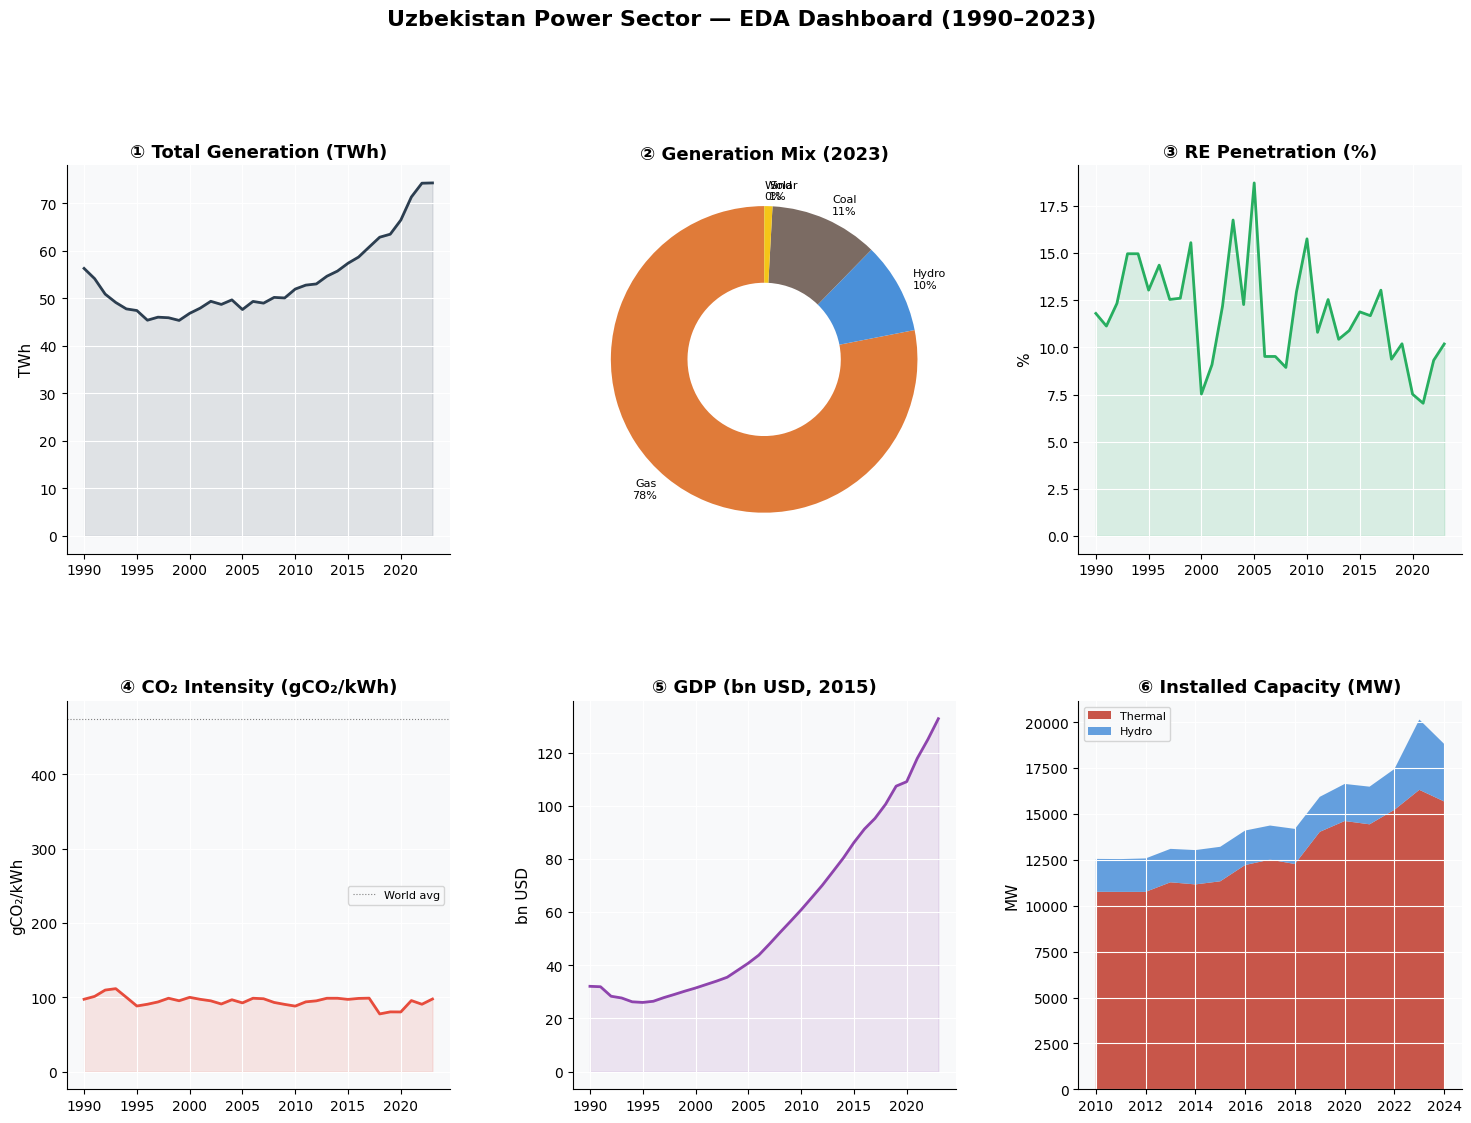

Dashboard saved to ../data/processed/eda_dashboard.png


In [22]:
# ── Summary dashboard: 6-panel figure ────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Uzbekistan Power Sector — EDA Dashboard (1990–2023)',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.32)

dc = df_confirmed.copy()

# 1. Total generation
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(dc['year'], dc['gen_total_twh_bridged'], color=COLORS['total'], lw=2)
ax1.fill_between(dc['year'], dc['gen_total_twh_bridged'], alpha=0.12, color=COLORS['total'])
ax1.set_title('① Total Generation (TWh)')
ax1.set_ylabel('TWh')

# 2. Generation mix donut — latest year
ax2 = fig.add_subplot(gs[0, 1])
latest = dc[['gen_gas_twh', 'gen_hydro_twh', 'gen_coal_twh', 'gen_solar_twh', 'gen_wind_twh']].fillna(0).iloc[-1]
wedge_labels = [f'Gas\n{latest["gen_gas_twh"]/latest.sum()*100:.0f}%',
                f'Hydro\n{latest["gen_hydro_twh"]/latest.sum()*100:.0f}%',
                f'Coal\n{latest["gen_coal_twh"]/latest.sum()*100:.0f}%',
                f'Solar\n{latest["gen_solar_twh"]/latest.sum()*100:.0f}%',
                f'Wind\n{latest["gen_wind_twh"]/latest.sum()*100:.0f}%']
ax2.pie(latest.values, labels=wedge_labels,
        colors=[COLORS['gas'], COLORS['hydro'], COLORS['coal'], COLORS['solar'], COLORS['wind']],
        startangle=90, wedgeprops={'width': 0.5},
        textprops={'fontsize': 8})
ax2.set_title(f'② Generation Mix ({int(dc["year"].iloc[-1])})')

# 3. RE share
ax3 = fig.add_subplot(gs[0, 2])
re_p = dc[['year', 're_penetration_pct']].dropna()
ax3.plot(re_p['year'], re_p['re_penetration_pct'], color=COLORS['renewable'], lw=2)
ax3.fill_between(re_p['year'], re_p['re_penetration_pct'], alpha=0.15, color=COLORS['renewable'])
ax3.set_title('③ RE Penetration (%)')
ax3.set_ylabel('%')

# 4. CO2 intensity
ax4 = fig.add_subplot(gs[1, 0])
ci_p = dc[['year', 'co2_intensity_power_gco2kwh']].dropna()
ax4.plot(ci_p['year'], ci_p['co2_intensity_power_gco2kwh'], color=COLORS['co2'], lw=2)
ax4.fill_between(ci_p['year'], ci_p['co2_intensity_power_gco2kwh'], alpha=0.12, color=COLORS['co2'])
ax4.axhline(475, color='grey', lw=0.8, linestyle=':', label='World avg')
ax4.set_title('④ CO₂ Intensity (gCO₂/kWh)')
ax4.set_ylabel('gCO₂/kWh')
ax4.legend(fontsize=8)

# 5. GDP
ax5 = fig.add_subplot(gs[1, 1])
gdp_p = dc[['year', 'wb_gdp_const2015_bn_usd']].dropna()
ax5.plot(gdp_p['year'], gdp_p['wb_gdp_const2015_bn_usd'], color=COLORS['gdp'], lw=2)
ax5.fill_between(gdp_p['year'], gdp_p['wb_gdp_const2015_bn_usd'], alpha=0.12, color=COLORS['gdp'])
ax5.set_title('⑤ GDP (bn USD, 2015)')
ax5.set_ylabel('bn USD')

# 6. Installed capacity
ax6 = fig.add_subplot(gs[1, 2])
cap_p = df[['year', 'capacity_total_mw', 'capacity_thermal_mw', 'capacity_hydro_mw']].dropna()
ax6.stackplot(cap_p['year'],
              [cap_p['capacity_thermal_mw'], cap_p['capacity_hydro_mw']],
              labels=['Thermal', 'Hydro'],
              colors=[COLORS['fossil'], COLORS['hydro']], alpha=0.85)
ax6.set_title('⑥ Installed Capacity (MW)')
ax6.set_ylabel('MW')
ax6.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('../data/processed/eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to ../data/processed/eda_dashboard.png')

In [23]:
# ── Key findings ──────────────────────────────────────────────────────
dc_c = df_confirmed.dropna(subset=['gen_total_twh_bridged', 'wb_gdp_const2015_bn_usd'])

gen_cagr = ((dc_c['gen_total_twh_bridged'].iloc[-1] / dc_c['gen_total_twh_bridged'].iloc[0]) **
             (1 / (dc_c['year'].iloc[-1] - dc_c['year'].iloc[0])) - 1) * 100
gdp_cagr = ((dc_c['wb_gdp_const2015_bn_usd'].iloc[-1] / dc_c['wb_gdp_const2015_bn_usd'].iloc[0]) **
             (1 / (dc_c['year'].iloc[-1] - dc_c['year'].iloc[0])) - 1) * 100

re_1990 = df_confirmed.loc[df_confirmed['year'] == 1990, 're_penetration_pct'].values
re_late = df_confirmed.loc[df_confirmed['year'] == 2023, 're_penetration_pct'].values

ci_early = df_confirmed.loc[df_confirmed['year'].between(1990, 2000), 'co2_intensity_power_gco2kwh'].mean()
ci_late  = df_confirmed.loc[df_confirmed['year'].between(2015, 2023), 'co2_intensity_power_gco2kwh'].mean()

print('=' * 62)
print('  KEY FINDINGS — Uzbekistan Power Sector EDA')
print('=' * 62)
print(f"""
GENERATION
  • Total generation CAGR (1990–2023): {gen_cagr:+.2f}%/yr
  • Peak generation:                   {dc_c['gen_total_twh_bridged'].max():.1f} TWh
  • Gas dominates the mix:             ~{dc_c[dc_c['year']==2023]['gen_gas_twh'].values[0]/dc_c[dc_c['year']==2023]['gen_total_twh_bridged'].values[0]*100:.0f}% in 2023

RENEWABLE ENERGY
  • RE share (1990): ~{re_1990[0]:.1f}% | RE share (2023): ~{re_late[0] if len(re_late) else '?'}%
  • Sector is overwhelmingly fossil-fuel dependent
  • Solar & wind remain negligible but growing rapidly post-2021

CARBON INTENSITY
  • Average 1990–2000: {ci_early:.0f} gCO₂/kWh
  • Average 2015–2023: {ci_late:.0f} gCO₂/kWh
  • Intensity has declined but remains above world average

ECONOMIC CONTEXT
  • GDP CAGR (1990–2023): {gdp_cagr:+.2f}%/yr
  • Strong correlation between GDP and electricity demand (r ≈ {dc_c['wb_gdp_const2015_bn_usd'].corr(dc_c['elec_consumption_twh_bridged']):.2f})
  • Electricity intensity of GDP declining → efficiency gains

DATA QUALITY
  • Core generation & consumption: complete 1990–2023
  • Installed capacity: available from 2010 only
  • Solar/Wind: sparse before 2018; use IRENA data as cross-check
  • 2024–2026: preliminary / forward estimates, treat with caution
""")
print('=' * 62)

  KEY FINDINGS — Uzbekistan Power Sector EDA

GENERATION
  • Total generation CAGR (1990–2023): +0.84%/yr
  • Peak generation:                   74.3 TWh
  • Gas dominates the mix:             ~76% in 2023

RENEWABLE ENERGY
  • RE share (1990): ~11.8% | RE share (2023): ~10.18351586255146%
  • Sector is overwhelmingly fossil-fuel dependent
  • Solar & wind remain negligible but growing rapidly post-2021

CARBON INTENSITY
  • Average 1990–2000: 99 gCO₂/kWh
  • Average 2015–2023: 91 gCO₂/kWh
  • Intensity has declined but remains above world average

ECONOMIC CONTEXT
  • GDP CAGR (1990–2023): +4.40%/yr
  • Strong correlation between GDP and electricity demand (r ≈ 0.84)
  • Electricity intensity of GDP declining → efficiency gains

DATA QUALITY
  • Core generation & consumption: complete 1990–2023
  • Installed capacity: available from 2010 only
  • Solar/Wind: sparse before 2018; use IRENA data as cross-check
  • 2024–2026: preliminary / forward estimates, treat with caution



---
### Next Steps (Notebook 03)
- Forecasting electricity demand (regression / ML models)
- Scenario analysis: RE targets vs baseline
- T&D loss decomposition (using sector-level consumption)
- CO₂ projection under different fuel-mix scenarios
- Comparison with regional peers (Kazakhstan, Kyrgyzstan)